In [ ]:
#|hide
import jax
from jax import numpy as jnp
import matplotlib.pyplot as plt
import pickle

from matplotlib.colors import ListedColormap
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as patches

custom_palette = ['#001733', '#13678A', '#60C7BB', '#FFFDA8']
cmap_blue = LinearSegmentedColormap.from_list("custom_cmap", ['#001733', '#13678A', '#60C7BB', '#FFFDA8'])
custom_palette = ['#0D090D','#365925','#DAF2B6']
cmap_green3 = LinearSegmentedColormap.from_list("custom_cmap", custom_palette)
custom_palette = ['#261B14','#D99962','#FDF0E9']
cmap_brown = LinearSegmentedColormap.from_list("custom_cmap", custom_palette)

This notebook presents how to use QDisc to reproduce the results on the classical shadows of the cluster Ising model. Its Hamiltoinian is given by

$$
H_{\mathrm{cluster}}
=  -\sum_{i=1}^{N} \sigma^z_{i-1} \sigma^x_i \sigma^z_{i+1}
   - h_1 \sum_{i=1}^{N} \sigma^x_i
    -h_2 \sum_{i=1}^{N-1}\sigma_i^x\sigma_{i+1}^x
$$

where $\sigma^x_i,\sigma^y_i,\sigma^z_i$ are Pauli operators acting on site $i$. We consider open boundary conditions defined by $\sigma^z_0 = \sigma^z_{N+1} = \mathbb{1}$. We sweep the
transverse-like field $h_1\in[0.05,\,1.20]$ and the Ising coupling $h_2\in[-1.5,\,1.5]$ to probe the competition between the cluster term, the transverse-field (paramagnetic) term, and nearest-neighbor Ising correlations.

## dataset and training

The dataset is produced by first computing the exact ground state wavefunction using Netket, similar to the J1J2 model (see tutorial). Then, classical shadows are generated by randomly sampling the Paulis and their respective outcomes using the probabilities given by the wavefunction. This is done using the `get_classical_shadow()` function from `QDisc.dataset`.

In [ ]:
## loading the exact wavefunction ##
with open('data_exact2_clusterN15.pkl', 'rb') as f:
    data_exact = pickle.load(f)

wave_fcts = data_exact['wave_fcts']

In [ ]:
## generating classical shadows across the parameter space ##
from qdisc.dataset.core import get_classical_shadow

N = 15
all_h1 = jnp.arange(0.05, 1.25, 0.05)
all_h2 = jnp.arange(-1.5, 1.5, 0.1)

num_sample_per_params = 2000
data = jnp.zeros([jnp.size(all_h1), jnp.size(all_h2), num_sample_per_params, 2*N])

key = jax.random.PRNGKey(12345)

wave_fcts = data_exact['wave_fcts']

for i, h1 in enumerate(all_h1):
    for j, h2 in enumerate(all_h2):
      key, subkey = jax.random.split(key)
      s = get_classical_shadow(psi=wave_fcts.astype('float32')[i,j], num_shots=num_sample_per_params, N=15, rng_key=subkey)
      data = data.at[i,j].set(s)

data = data.astype('int32')


In [ ]:
## casting everything in a QDisc Dataset object ##
from qdisc.dataset.core import Dataset

dataset = Dataset(data=data, thetas=[all_h1, all_h2], data_type='shadow', local_dimension=2, local_states=jnp.array([0,1]))

In [ ]:
## We use the transformer architecture for the encoder and decoder ##
from qdisc.nn.core import Transformer_encoder
from qdisc.nn.core import Transformer_decoder
from qdisc.vae.core import VAEmodel

encoder = Transformer_encoder(latent_dim=5, d_model=16, num_heads=2, num_layers=3, data_type='shadow')
decoder = Transformer_decoder(d_model=32, num_heads=4, num_layers=3, data_type='shadow')

myvae = VAEmodel(encoder=encoder, decoder=decoder)

In [ ]:
## Training ##
from qdisc.vae.core import VAETrainer

myvaetrainer = VAETrainer(model=myvae, dataset=dataset)
key = jax.random.PRNGKey(67483)
num_epochs = 1000
myvaetrainer.train(num_epochs=num_epochs, batch_size=10000, beta=0.65, gamma=0., key=key, printing_rate=50, re_shuffle=True)

Start training...
epoch=0 step=0 loss=12.347687967698652 recon=10.325565010988841
logvar=[-0.33022366  0.0294409   0.55953395  0.33956828 -0.45126546]
epoch=50 step=0 loss=6.487059499221326 recon=2.747702826860476
logvar=[ 1.60891616e-03 -3.79395645e+00 -5.48110009e+00 -2.10693801e+00
  5.09911842e-03]
epoch=100 step=0 loss=6.315230991856255 recon=2.176506179580368
logvar=[-2.18324061e-04 -4.26282124e+00 -5.74415987e+00 -2.89566177e+00
  4.52455450e-04]
epoch=150 step=0 loss=6.351402070119837 recon=2.0416517952765454
logvar=[-5.49586326e-03 -4.39419643e+00 -5.77676345e+00 -3.12499072e+00
 -1.05409432e-03]
epoch=200 step=0 loss=6.185613846957846 recon=1.7170996274912897
logvar=[-1.38495516e-03 -4.54206555e+00 -5.94358400e+00 -3.26664121e+00
 -4.34269675e-03]
epoch=250 step=0 loss=6.050364744366315 recon=1.5615449391153347
logvar=[-1.69562970e-03 -4.60882494e+00 -5.98703399e+00 -3.21580383e+00
 -2.02698014e-03]
epoch=300 step=0 loss=6.036482538330654 recon=1.4641840750033226
logvar=[-3.2

In [ ]:
#load the trained model
from qdisc.vae.core import VAETrainer
with open('clusterIsingN15_data_cpVAE2_QDisc.pkl', 'rb') as f:
    all_data = pickle.load(f)

myvaetrainer = VAETrainer(model=myvae, dataset=dataset)

myvaetrainer.init_state(jax.random.PRNGKey(0), dataset.data[0,0])
myvaetrainer.state = myvaetrainer.state.replace(params=all_data['params'])
num_epochs = 1000
myvaetrainer.history_recon = all_data['history_recon']
myvaetrainer.history_logvar = all_data['history_logvar']

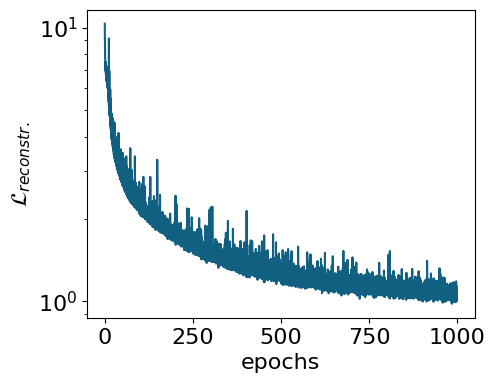

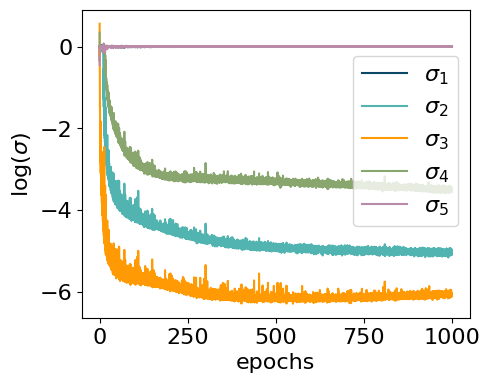

In [ ]:
## plot the training ##
myvaetrainer.plot_training(num_epochs = num_epochs)

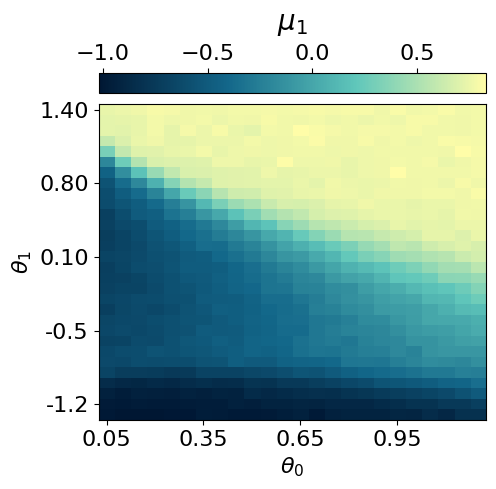

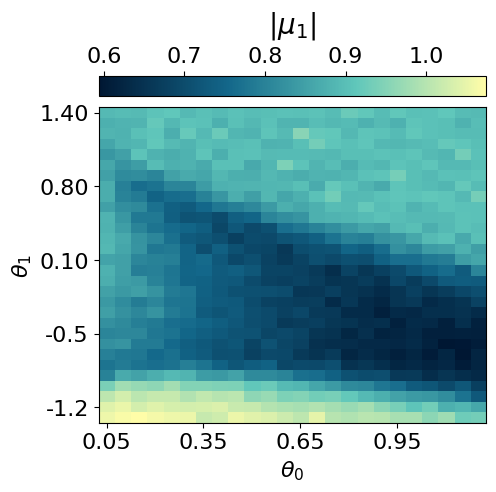

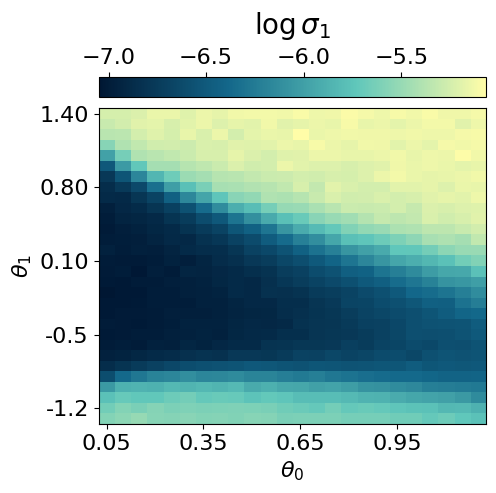

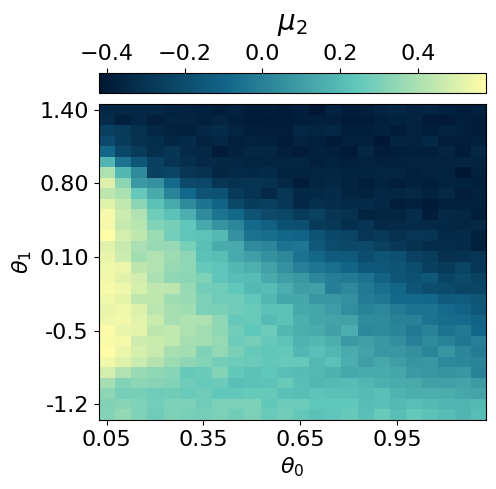

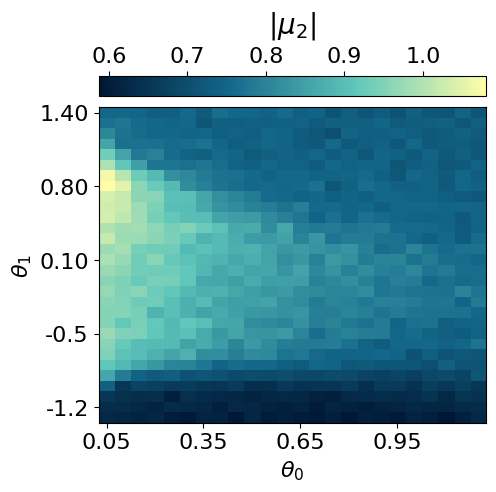

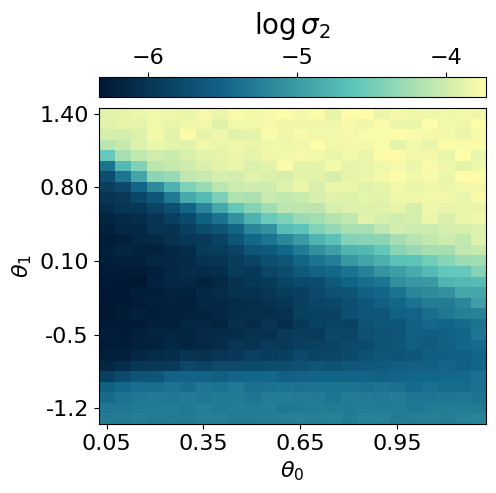

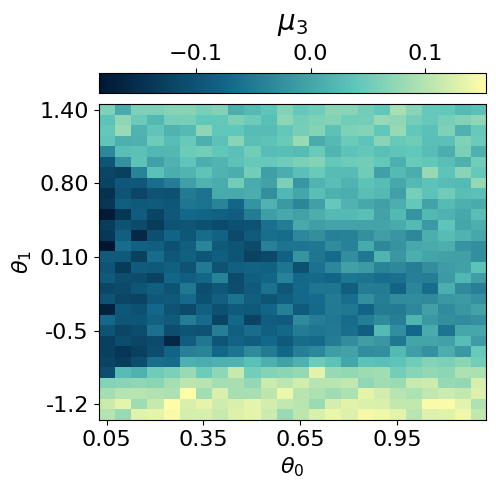

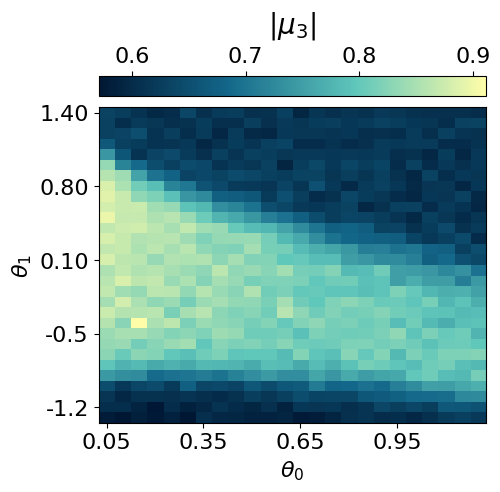

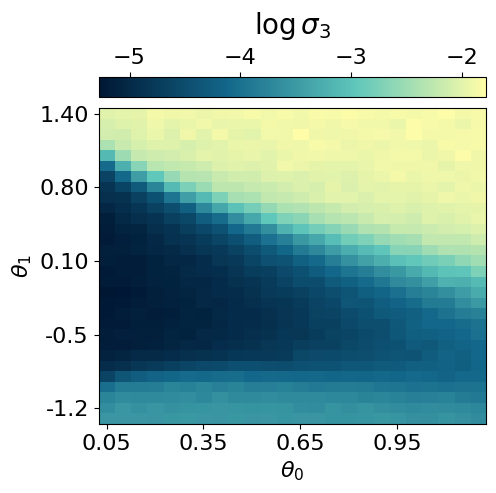

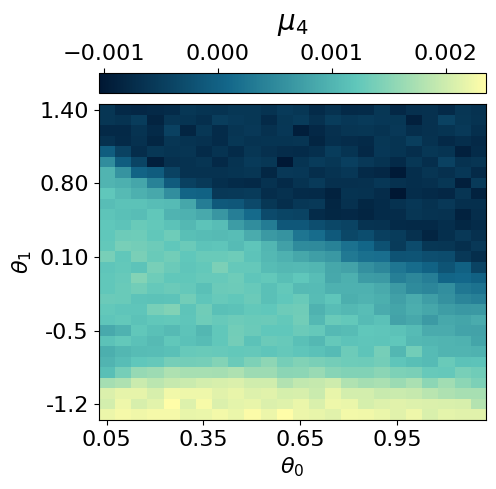

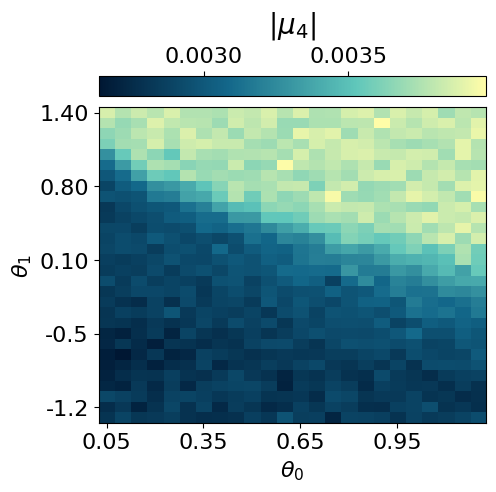

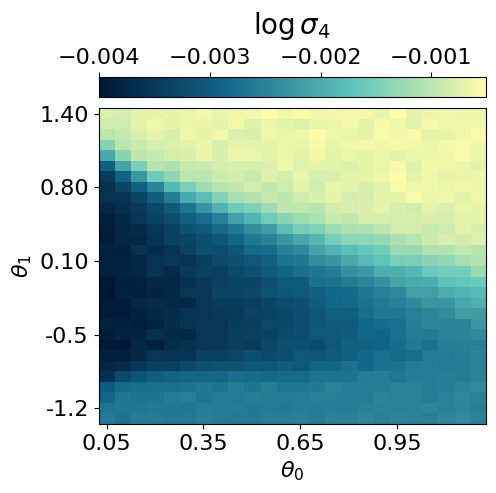

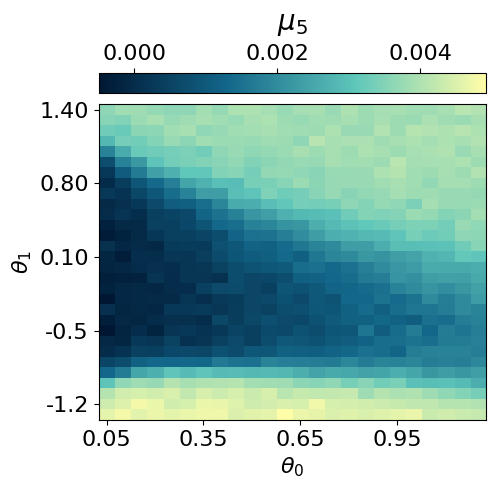

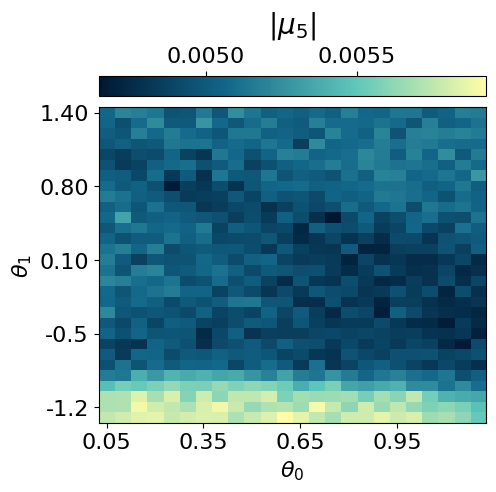

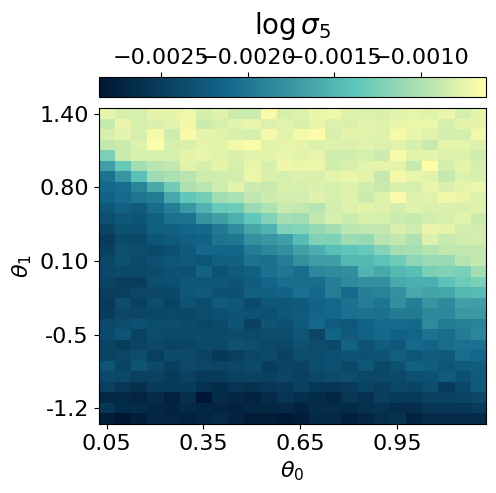

In [ ]:
## compute and plot the representation ##
myvaetrainer.compute_and_plot_repr2d(subplot=False)

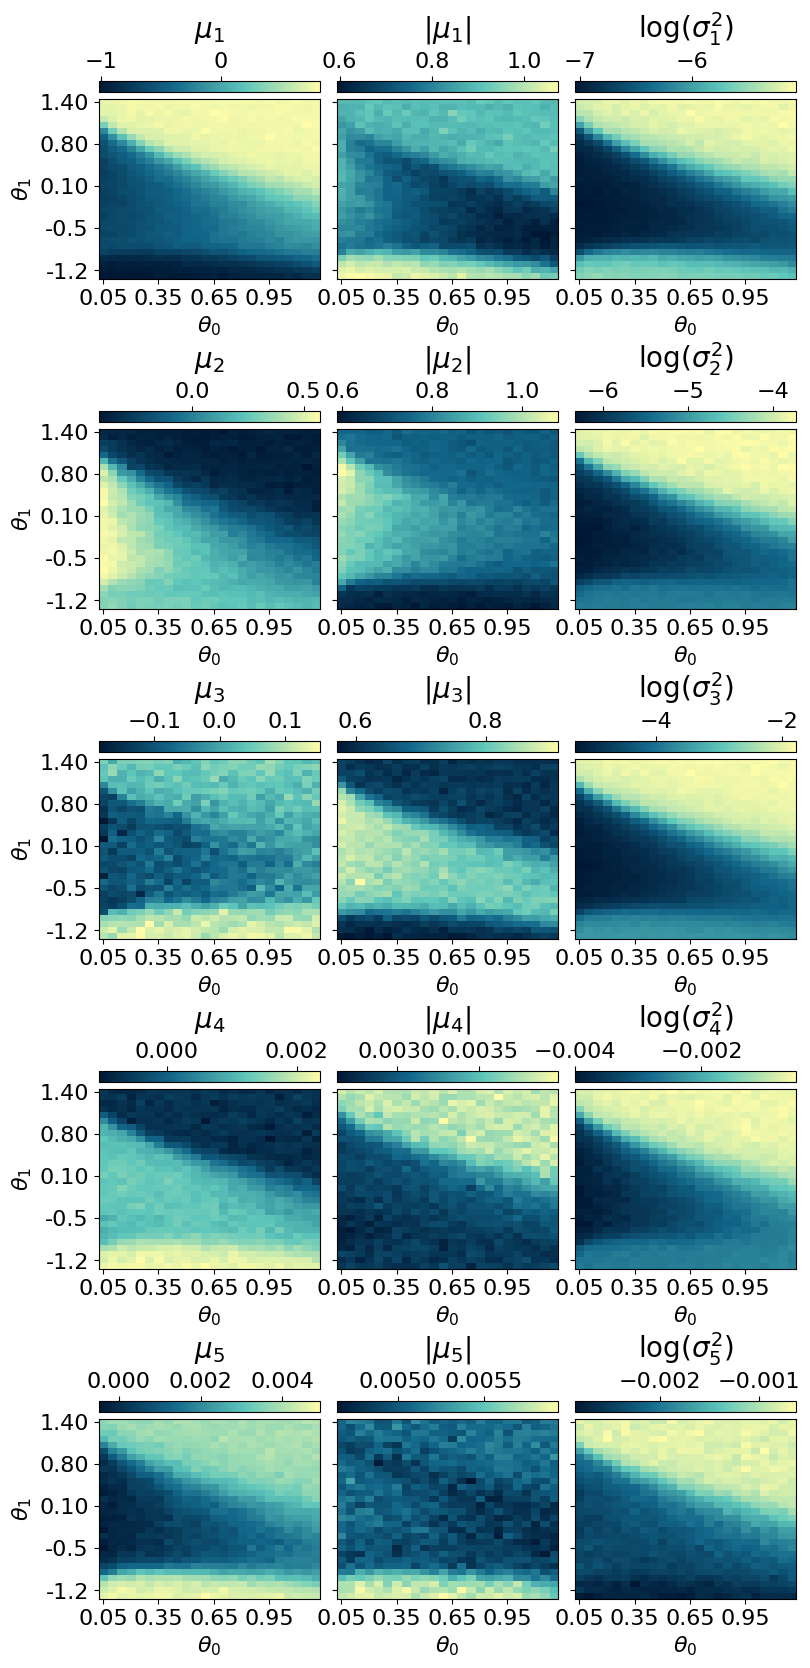

In [ ]:
# or plot using subplots (more compact)
myvaetrainer.plot_repr2d(subplot=True)

In [ ]:
all_data = myvaetrainer.get_data()

with open('clusterIsingN15_data_cpVAE2_QDisc.pkl', 'wb') as f:
    pickle.dump(all_data, f)

## Reconstruction of physical quantities

In this section, we analyze how the **cpVAE can reconstruct physical quantities**, such as energy and stabilizers. We first reconstruct each shadows and then compute the **Median-of-means estimate** of the various observables.

In [ ]:
## shadows reconstruction, from testset random measurements ##

# generate random measurement
N = 15
all_h1 = jnp.arange(0.05, 1.25, 0.05)
all_h2 = jnp.arange(-1.5, 1.5, 0.1)

num_sample_per_params = 2000
test_data = jnp.zeros([jnp.size(all_h1), jnp.size(all_h2), num_sample_per_params, 2*N])

key = jax.random.PRNGKey(7654)

wave_fcts = data_exact['wave_fcts']

for i, h1 in enumerate(all_h1):
    for j, h2 in enumerate(all_h2):
      #we dont need the measurement output but just the random basis. Easier to just use the function already inplemented and ignore the output
      key, subkey = jax.random.split(key)
      s = get_classical_shadow(psi=wave_fcts.astype('float32')[i,j], num_shots=num_sample_per_params, N=15, rng_key=subkey)
      test_data = test_data.at[i,j].set(s)

test_data = test_data.astype('int32')

# use the decoder to predict the outcomes of each shadows

key = jax.random.PRNGKey(347856)
S_reconstructed = jnp.zeros_like(test_data)

for i, h1 in enumerate(all_h1):
    for j, h2 in enumerate(all_h2):
        d = test_data[i,j]
        key, subkey = jax.random.split(key)
        s = myvaetrainer.reconstruct_sample(d, subkey)
        S_reconstructed = S_reconstructed.at[i,j].set(s)


In [ ]:
## estimate of the energy ##
@jax.jit
def sqe_cal_energy(sqe: jnp.ndarray,
                   J_cluster: float,
                   h1: float,
                   h2: float) -> jnp.ndarray:
    """
    Estimate ⟨H⟩ from a batch of classical‐shadows `sqe` of shape (T, 2*num_bits),
    where columns alternate (basis, outcome), with basis encoded {X→2, Y→3, Z→4}
    and outcome ∈ {0,1}. Returns the average energy over the batch.
    """
    # split into per‐site basis and outcome
    basis   = sqe[:, 0::2]   # shape (T, num_bits)
    outcome = sqe[:, 1::2]   # shape (T, num_bits)

    # single‐shot estimators: ±3 for X and Z, zero otherwise
    expX = jnp.where(basis == 2,
                     jnp.where(outcome == 1, +3.0, -3.0),
                     0.0)
    expZ = jnp.where(basis == 4,
                     jnp.where(outcome == 1, +3.0, -3.0),
                     0.0)

    # two‐site and three‐site terms
    expXX  = expX[:, :-1] * expX[:, 1:]          # shape (T, num_bits-1)
    expZXZ = expZ[:, :-2] * expX[:, 1:-1] * expZ[:, 2:]  # shape (T, num_bits-2)

    # sums per snapshot
    sumZXZ = expZXZ.sum(axis=1)   # (T,)
    sumX   = expX.sum(axis=1)     # (T,)
    sumXX  = expXX.sum(axis=1)    # (T,)

    # instantaneous energies, then mean over T
    energies = -sumZXZ * J_cluster - sumX * h1 - sumXX * h2
    return energies.mean()


def MoM_energy(J_cluster: float,
               h1: float,
               h2: float,
               sqe: jnp.ndarray,
               num_parts: int) -> jnp.ndarray:
    """
    Median‐of‐means estimate of ⟨H⟩ from shadows `sqe` of shape (T, 2*num_bits),
    partitioned into `num_parts` blocks of equal size.
    """
    T = sqe.shape[0]
    part_size = T // num_parts
    if part_size * num_parts != T:
        raise ValueError(f"T={T} not divisible by num_parts={num_parts}")

    # compute block‐means
    means = []
    for k in range(num_parts):
        block = sqe[k*part_size:(k+1)*part_size]
        means.append(sqe_cal_energy(block, J_cluster, h1, h2))
    means = jnp.stack(means)  # (num_parts,)

    # return the median of the block‐means
    return jnp.median(means)


In [ ]:
energy_from_dataset = jnp.zeros((len(all_h1),len(all_h2)))

for i, h1 in enumerate(all_h1):
    for j, h2 in enumerate(all_h2):
        energy_from_dataset = energy_from_dataset.at[i,j].set(MoM_energy(J_cluster=1.0, h1=h1, h2=h2, sqe=dataset.data[i,j], num_parts=10))


energy_recon = jnp.zeros((len(all_h1),len(all_h2)))

for i, h1 in enumerate(all_h1):
    for j, h2 in enumerate(all_h2):
        energy_recon = energy_recon.at[i,j].set(MoM_energy(J_cluster=1.0, h1=h1, h2=h2, sqe=S_reconstructed[i,j], num_parts=10))

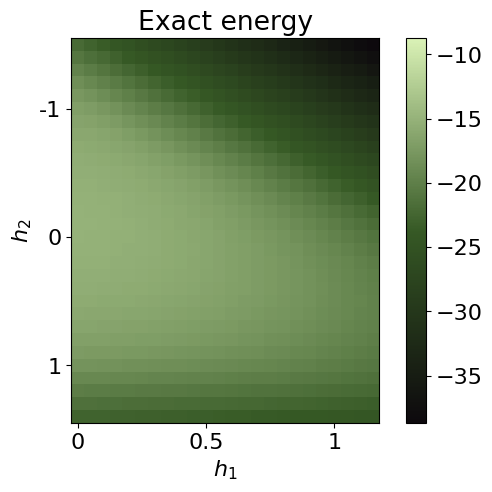

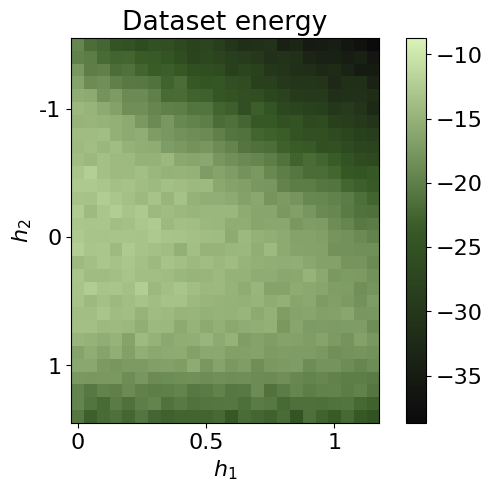

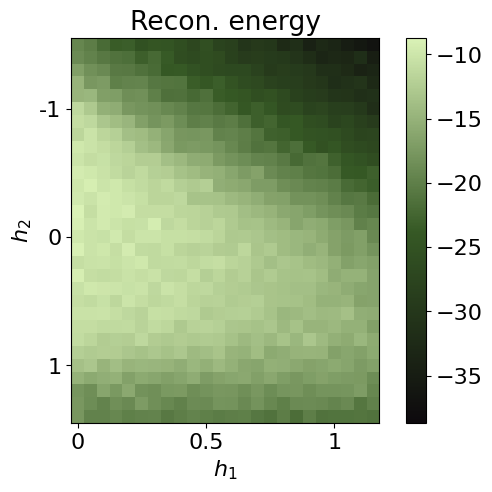

In [ ]:
exact_energies = data_exact['energies']
#energy_from_dataset = clusterIsingN15_VAE2_reconstruction['energy_from_dataset']
#energy_recon = clusterIsingN15_VAE2_reconstruction['energy_recon']

energy_max = jnp.max(jnp.array([jnp.max(exact_energies),jnp.max(energy_from_dataset),jnp.max(energy_recon)]))
energy_min = jnp.min(jnp.array([jnp.min(exact_energies),jnp.min(energy_from_dataset),jnp.min(energy_recon)]))


plt.rcParams['font.size'] = 16
plt.figure(figsize=(7,5),dpi=100)


plt.imshow(jnp.rot90(exact_energies),cmap=cmap_green3, vmin=energy_min, vmax=energy_max)
plt.colorbar()
plt.title(r'Exact energy')
plt.xlabel(r'$h_1$')
plt.ylabel(r'$h_2$')
plt.xticks([0,10,20], [0,0.5,1])
plt.yticks([5,15,25], [-1,0,1])
plt.show()



plt.rcParams['font.size'] = 16
plt.figure(figsize=(7,5),dpi=100)


plt.imshow(jnp.rot90(energy_from_dataset),cmap=cmap_green3, vmin=energy_min, vmax=energy_max)
plt.colorbar()
plt.title(r'Dataset energy')
plt.xlabel(r'$h_1$')
plt.ylabel(r'$h_2$')
plt.xticks([0,10,20], [0,0.5,1])
plt.yticks([5,15,25], [-1,0,1])
plt.show()


plt.rcParams['font.size'] = 16
plt.figure(figsize=(7,5),dpi=100)


plt.imshow(jnp.rot90(energy_recon),cmap=cmap_green3, vmin=energy_min, vmax=energy_max)
plt.colorbar()
plt.title(r'Recon. energy')
plt.xlabel(r'$h_1$')
plt.ylabel(r'$h_2$')
plt.xticks([0,10,20], [0,0.5,1])
plt.yticks([5,15,25], [-1,0,1])
plt.show()


In [ ]:
energies = {}
energies['exact'] = exact_energies
energies['dataset'] = energy_from_dataset
energies['recon'] = energy_recon

data['energies'] = energies

In [ ]:
 ## same for the stabilizers ##
@jax.jit
def sqe_cal_stab(sqe: jnp.ndarray) -> jnp.ndarray:

    # split into per‐site basis and outcome
    basis   = sqe[:, 0::2]   # shape (T, num_bits)
    outcome = sqe[:, 1::2]   # shape (T, num_bits)

    expX = jnp.where(basis == 2,
                     jnp.where(outcome == 1, +3.0, -3.0),
                     0.0)
    expZ = jnp.where(basis == 4,
                     jnp.where(outcome == 1, +3.0, -3.0), #3 for unbiased estim (see classical shadows th.)
                     0.0)
    all_ZX_XZ = []
    for i in range(2,N):
      expZX_XZ = expZ[:, :-i]
      for j in range(1,i):
        expZX_XZ = expZX_XZ * expX[:, j:-i+j]
      expZX_XZ = expZX_XZ * expZ[:, i:]

      #sums per samples
      ZX_XZ = expZX_XZ.sum(axis=1).mean()

      all_ZX_XZ.append(ZX_XZ)



    all_ZX_XZ = jnp.array(all_ZX_XZ)    # shape

    return all_ZX_XZ


def MoM_stab(sqe: jnp.ndarray,
               num_parts: int) -> jnp.ndarray:
    """
    Median‐of‐means estimate of ⟨H⟩ from shadows `sqe` of shape (T, 2*num_bits),
    partitioned into `num_parts` blocks of equal size.
    """
    T = sqe.shape[0]
    part_size = T // num_parts
    if part_size * num_parts != T:
        raise ValueError(f"T={T} not divisible by num_parts={num_parts}")

    # compute block‐means
    means = []
    for k in range(num_parts):
        block = sqe[k*part_size:(k+1)*part_size]
        means.append(sqe_cal_stab(block))
    means = jnp.stack(means)  # (num_parts,k)

    # return the median of the block‐means
    return jnp.median(means, axis=0)


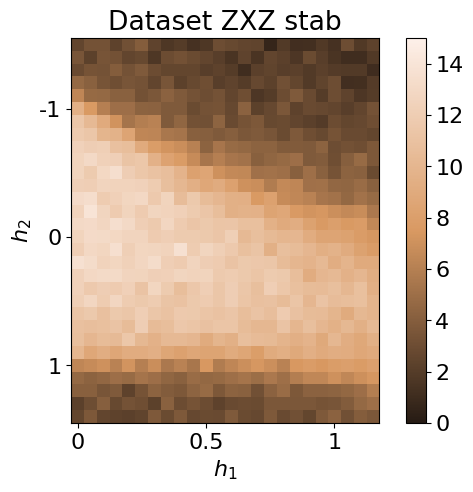

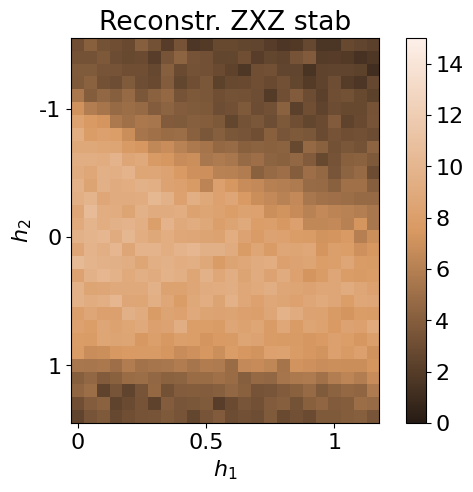

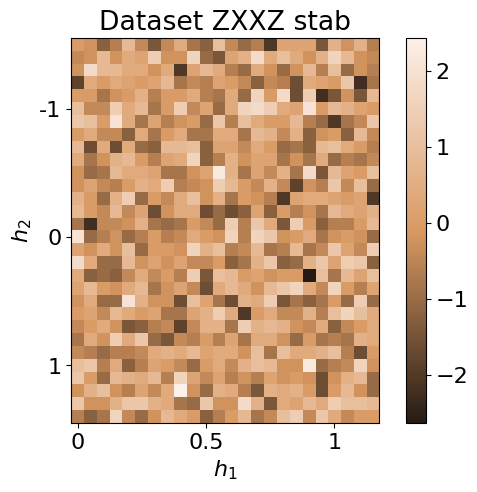

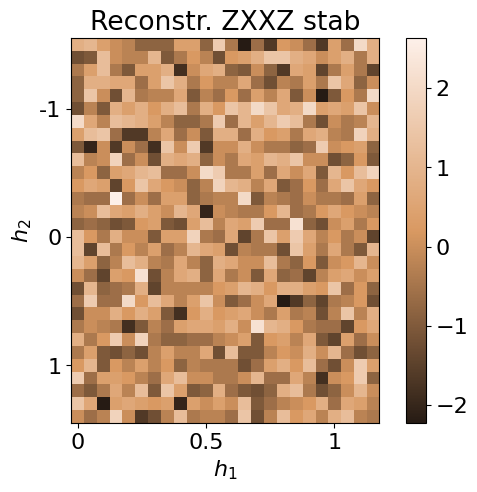

In [ ]:
stab_dataset = jnp.zeros((len(all_h1),len(all_h2),N-2))

for i, h1 in enumerate(all_h1):
    for j, h2 in enumerate(all_h2):
      stab = MoM_stab(sqe=dataset.data[i,j], num_parts=10)
      stab_dataset = stab_dataset.at[i,j].set(stab)

stab_recon = jnp.zeros((len(all_h1),len(all_h2),N-2))

for i, h1 in enumerate(all_h1):
    for j, h2 in enumerate(all_h2):
      stab = MoM_stab(sqe=S_reconstructed[i,j], num_parts=10)
      stab_recon = stab_recon.at[i,j].set(stab)

plt.rcParams['font.size'] = 16
plt.figure(figsize=(7,5),dpi=100)

plt.imshow(jnp.rot90(stab_dataset[...,0]),cmap=cmap_brown, vmin=0, vmax=N)
plt.colorbar()
plt.title(r'Dataset ZXZ stab')
plt.xlabel(r'$h_1$')
plt.ylabel(r'$h_2$')
plt.xticks([0,10,20], [0,0.5,1])
plt.yticks([5,15,25], [-1,0,1])
plt.show()


plt.rcParams['font.size'] = 16
plt.figure(figsize=(7,5),dpi=100)

plt.imshow(jnp.rot90(stab_recon[...,0]),cmap=cmap_brown, vmin=0, vmax=N)
plt.colorbar()
plt.title(r'Reconstr. ZXZ stab')
plt.xlabel(r'$h_1$')
plt.ylabel(r'$h_2$')
plt.xticks([0,10,20], [0,0.5,1])
plt.yticks([5,15,25], [-1,0,1])
plt.show()

plt.rcParams['font.size'] = 16
plt.figure(figsize=(7,5),dpi=100)

plt.imshow(jnp.rot90(stab_dataset[...,1]),cmap=cmap_brown)
plt.colorbar()
plt.title(r'Dataset ZXXZ stab')
plt.xlabel(r'$h_1$')
plt.ylabel(r'$h_2$')
plt.xticks([0,10,20], [0,0.5,1])
plt.yticks([5,15,25], [-1,0,1])
plt.show()


plt.rcParams['font.size'] = 16
plt.figure(figsize=(7,5),dpi=100)

plt.imshow(jnp.rot90(stab_recon[...,1]),cmap=cmap_brown)
plt.colorbar()
plt.title(r'Reconstr. ZXXZ stab')
plt.xlabel(r'$h_1$')
plt.ylabel(r'$h_2$')
plt.xticks([0,10,20], [0,0.5,1])
plt.yticks([5,15,25], [-1,0,1])
plt.show()


In [ ]:
data['stabilizers'] = {}
data['stabilizers']['dataset'] = stab_dataset
data['stabilizers']['recon'] = stab_recon

In [ ]:
with open('clusterIsingN15_data_cpVAE2_QDisc.pkl', 'wb') as f:
    pickle.dump(data, f)

## Symbolic regression

In this section, we employ `QDisc.SR.SymbolicRegression` to investigate the **nature of the additional cluster** observed in the latent representation. We will use the `'2_body_correlator'` ansatz with the **SR1** objective.

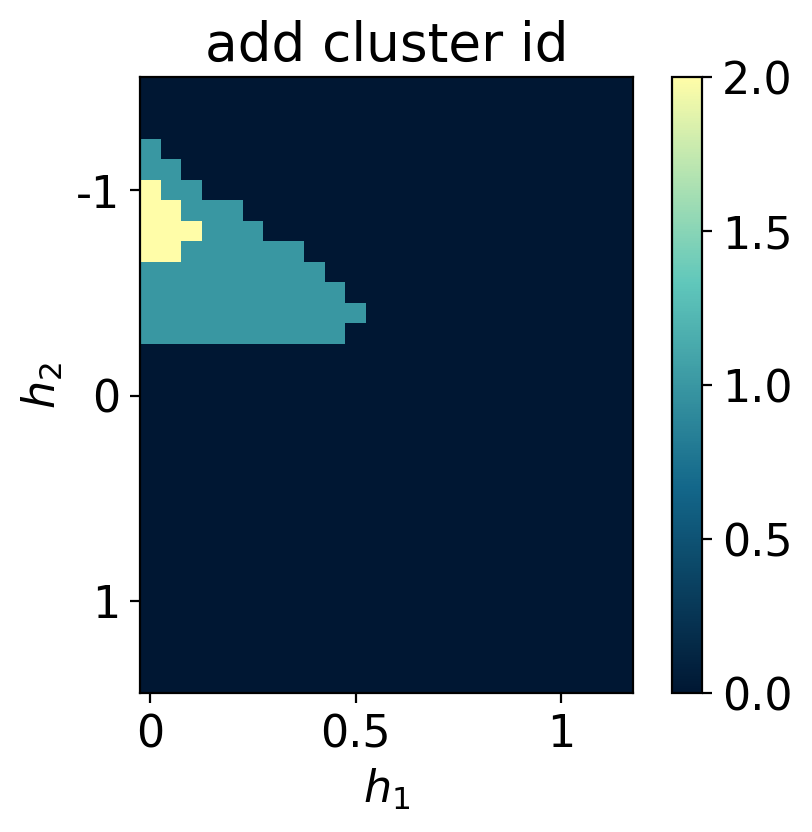

In [ ]:
## specifying the index of the cluster and the 'out' data ##

idx_add_cluster = jnp.array([[ 0, 21],
       [ 0, 22],
       [ 0, 23],
       [ 0, 24],
       [ 1, 21],
       [ 1, 22],
       [ 1, 23],
       [ 2, 22]])

idx_add_cluster2 = jnp.array([[ 0, 17],
       [ 0, 18],
       [ 0, 19],
       [ 0, 20],
       [ 0, 21],
       [ 0, 22],
       [ 0, 23],
       [ 0, 24],
       [ 0, 25],
       [ 0, 26],
       [ 1, 17],
       [ 1, 18],
       [ 1, 19],
       [ 1, 20],
       [ 1, 21],
       [ 1, 22],
       [ 1, 23],
       [ 1, 24],
       [ 1, 25],
       [ 2, 17],
       [ 2, 18],
       [ 2, 19],
       [ 2, 20],
       [ 2, 21],
       [ 2, 22],
       [ 2, 23],
       [ 2, 24],
       [ 3, 17],
       [ 3, 18],
       [ 3, 19],
       [ 3, 20],
       [ 3, 21],
       [ 3, 22],
       [ 3, 23],
       [ 4, 17],
       [ 4, 18],
       [ 4, 19],
       [ 4, 20],
       [ 4, 21],
       [ 4, 22],
       [ 4, 23],
       [ 5, 17],
       [ 5, 18],
       [ 5, 19],
       [ 5, 20],
       [ 5, 21],
       [ 5, 22],
       [ 6, 17],
       [ 6, 18],
       [ 6, 19],
       [ 6, 20],
       [ 6, 21],
       [ 7, 17],
       [ 7, 18],
       [ 7, 19],
       [ 7, 20],
       [ 7, 21],
       [ 8, 17],
       [ 8, 18],
       [ 8, 19],
       [ 8, 20],
       [ 9, 17],
       [ 9, 18],
       [ 9, 19],
       [10, 18]])

array_add_cluster = jnp.zeros((len(all_h1),len(all_h2)))

for i,j in idx_add_cluster:
  array_add_cluster = array_add_cluster.at[i,j].set(1)

for i,j in idx_add_cluster2:
  array_add_cluster = array_add_cluster.at[i,j].add(1)


plt.rcParams['font.size'] = 16
plt.figure(figsize=(5,4),dpi=200)


plt.imshow(jnp.rot90(array_add_cluster ),cmap=cmap_blue)
plt.colorbar()
plt.title(r'add cluster id')
plt.xlabel(r'$h_1$')
plt.ylabel(r'$h_2$')
plt.xticks([0,10,20], [0,0.5,1])
plt.yticks([5,15,25], [-1,0,1])
plt.show()

In [ ]:
## try using only Z measurements ##
N = 15
all_h1 = jnp.arange(0.05, 1.25, 0.05)
all_h2 = jnp.arange(-1.5, 1.5, 0.1)

num_sample_per_params = 2000
data = jnp.zeros([jnp.size(all_h1), jnp.size(all_h2), num_sample_per_params, 2*N])

key = jax.random.PRNGKey(12345)

wave_fcts = data_exact['wave_fcts']

for i, h1 in enumerate(all_h1):
    for j, h2 in enumerate(all_h2):
      key, subkey = jax.random.split(key)
      s = get_classical_shadow(psi=wave_fcts.astype('float32')[i,j], num_shots=num_sample_per_params, N=15, rng_key=subkey, bases='Z')
      data = data.at[i,j].set(s)

data = data.astype('int32')[...,1::2]

dataset_onlyZ = Dataset(data=data, thetas=[all_h1, all_h2], data_type='shadow', local_dimension=2, local_states=jnp.array([0,1]))

In [ ]:
## 2BC with SR1 on just Z measurements ##
from qdisc.sr.core import SymbolicRegression

cluster_idx_out = jnp.argwhere(array_add_cluster == 0)


mySR = SymbolicRegression(dataset_onlyZ,
                          cluster_idx_in=idx_add_cluster,
                          cluster_idx_out=cluster_idx_out,
                          objective='SR1',
                          shift_data=False)

key = jax.random.PRNGKey(7654)
modelSR1 = mySR.train_2BC(key, dataset_size=10000)

## plot the alpha ##
topology = [[i for i in range(N)]]
mySR.plot_alpha(topology=topology, edge_scale=5, name='SR1')

## plot the prediction ##
p = mySR.compute_and_plot_prediction(name='SR1')



In [ ]:
## try using only X measurements ##
N = 15
all_h1 = jnp.arange(0.05, 1.25, 0.05)
all_h2 = jnp.arange(-1.5, 1.5, 0.1)

num_sample_per_params = 2000
data = jnp.zeros([jnp.size(all_h1), jnp.size(all_h2), num_sample_per_params, 2*N])

key = jax.random.PRNGKey(12345)

wave_fcts = data_exact['wave_fcts']

for i, h1 in enumerate(all_h1):
    for j, h2 in enumerate(all_h2):
      key, subkey = jax.random.split(key)
      s = get_classical_shadow(psi=wave_fcts.astype('float32')[i,j], num_shots=num_sample_per_params, N=15, rng_key=subkey, bases='X')
      data = data.at[i,j].set(s)

data = data.astype('int32')[...,1::2]

dataset_onlyX = Dataset(data=data, thetas=[all_h1, all_h2], data_type='shadow', local_dimension=2, local_states=jnp.array([0,1]))

### Start preparing the dataset ###
### Dataset prepared, start the trainnig ###
### Training finished ###
  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 0.5106711659251788
        x: [ 1.540e+00  3.770e-02 ...  2.136e-01  1.452e+00]
      nit: 55
      jac: [ 2.176e-06  2.887e-06 ...  1.443e-06  6.439e-07]
     nfev: 6678
     njev: 63
 hess_inv: <105x105 LbfgsInvHessProduct with dtype=float64>


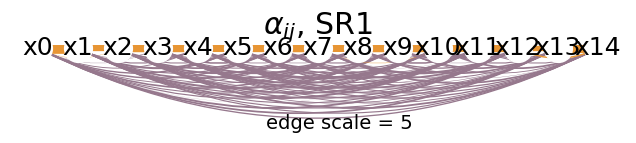

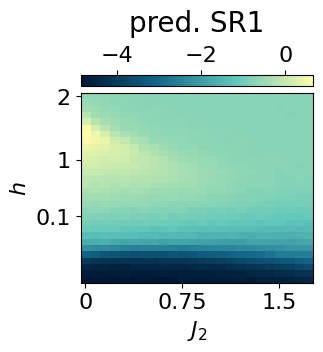

In [ ]:
## 2BC ansatz with SR1 on just X measurements ##

cluster_idx_out = jnp.argwhere(array_add_cluster == 0)


mySR = SymbolicRegression(dataset_onlyX,
                          cluster_idx_in=idx_add_cluster,
                          cluster_idx_out=cluster_idx_out,
                          objective='SR1',
                          shift_data=False)

key = jax.random.PRNGKey(7654)
modelSR1 = mySR.train_2BC(key, dataset_size=10000)

## plot the alpha ##
topology = [[i for i in range(N)]]
mySR.plot_alpha(topology=topology, edge_scale=5, name='SR1')

## plot the prediction ##
p = mySR.compute_and_plot_prediction(name='SR1')



In [ ]:
alpha_ij = mySR.model.alpha
alpha_ij

array([ 1.53990705,  0.03770259, -0.04346825, -0.13149565, -0.20346243,
       -0.216187  , -0.12516161, -0.23463057, -0.14797347, -0.16969701,
       -0.01672046, -0.26892908, -0.251428  , -0.18952416,  0.90347631,
       -0.07494612, -0.16222789, -0.29326692, -0.17400529, -0.26595568,
       -0.12645806, -0.2897381 , -0.16483247, -0.27759441, -0.1555185 ,
       -0.16111236, -0.16457265,  1.06849548, -0.24298301, -0.14912591,
       -0.24760999, -0.27366484, -0.23243181, -0.16129378, -0.11605931,
       -0.27185235, -0.19379922, -0.1133317 , -0.25916324,  1.05848648,
       -0.16312015, -0.21815877, -0.14621403, -0.29572144, -0.15435303,
       -0.29049595, -0.33689923, -0.14333938, -0.17874212, -0.12713576,
        1.15864417, -0.17555103, -0.11184462, -0.2233854 , -0.11609519,
       -0.40802327, -0.16249469, -0.26187147, -0.1974241 , -0.19273916,
        1.04689131, -0.18818199, -0.08297489, -0.2684967 , -0.21047272,
       -0.27824555, -0.07299964, -0.13854064, -0.16618549,  1.07

we can further reduce the form of $f(x)$ by mapping the 2 body weights $\alpha_{ij}$ to a compact analytical formula. This can be done using the `reduce_alpha()` method.

In [ ]:
g = mySR.reduce_alpha(random_state = 5732)

PySRRegressor imported


/usr/local/lib/python3.12/dist-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 6.080e+04
Progress: 319 / 6200 total iterations (5.145%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.035e-01  0.000e+00  y = -0.0070507
3           1.909e-01  3.189e-02  y = 0.63834 / x₁
5           1.358e-01  1.702e-01  y = 0.57163 / (x₁ - x₀)
7           2.778e-02  7.935e-01  y = -0.20651 / ((x₁ - x₀) + -1.1858)
9           1.197e-02  4.208e-01  y = (-0.14197 / (0.89362 - (x₁ - x₀))) + -0.22225
19          1.191e-02  4.953e-04  y = ((x₁ / (x₁ * ((((x₁ - 1.1846) - (x₀ - x₁)) - 0.61262) ...
                                      - x₀))) * 0.26971) - 0.22255
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════

[ Info: Final population:
[ Info: Results saved to:



Expressions evaluated per second: 9.130e+04
Progress: 5253 / 6200 total iterations (84.726%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.035e-01  0.000e+00  y = -0.0070507
3           1.909e-01  3.189e-02  y = 0.63864 / x₁
5           1.357e-01  1.705e-01  y = -0.59076 / (x₀ - x₁)
7           2.778e-02  7.932e-01  y = -0.20667 / ((x₁ + -1.1858) - x₀)
9           1.168e-02  4.333e-01  y = (-0.070507 / (0.94622 - (x₁ - x₀))) + -0.20238
13          1.062e-02  2.373e-02  y = (-0.085704 / ((0.016837 / x₁) - (x₁ - (0.93069 + x₀)))...
                                      ) + -0.20749
15          9.731e-03  4.376e-02  y = (-0.13525 / ((0.011703 / (0.53637 - x₀)) - (x₁ - (x₀ +...
                                       0.89961)))) + -0.22209
17          9.407e-03  1.694e-02  y = ((-0

In [ ]:
print(g)

(-0.20237744*x0 + 0.20237744*x1 - 0.261999786885912)/(x0 - x1 + 0.94621605)
